## Clustering

# ML - Aprendizaje No Supervisado

En la mayoría de los casos, nuestros datos no vienen con etiquetas. Etiquetarlos manualmente puede ser costoso y llevar mucho tiempo. Por eso existen técnicas de aprendizaje no supervisado (*Unsupervised Learning*), que nos permiten analizar y descubrir patrones en los datos sin necesidad de etiquetas previas.

El *Clustering* es una técnica popular de aprendizaje no supervisado que agrupa datos similares en conjuntos llamados *clusters*. Esto ayuda a descubrir patrones y segmentar información, siendo útil en áreas como la segmentación de clientes, análisis de datos, reducción de dimensiones, detección de anomalías y motores de búsqueda.

### K-Means

El algoritmo de *K-Means* es uno de los más usados a la hora de aplicar *Clustering*, ya que es un método rápido y eficiente. Vamos a generar un conjunto de datos sintético para aprender a usar esta técnica.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import random

n_centers = random.randint(1, 20)

blob_centers = []
while len(blob_centers) < n_centers:
    candidate = np.random.uniform(-10, 10, size=2)
    if all(np.linalg.norm(candidate - center) > 2 for center in blob_centers):
        blob_centers.append(candidate)

blob_centers = np.array(blob_centers)
blob_std = np.full(n_centers, 2.0)  

from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=2000, centers=blob_centers,
                  cluster_std=blob_std, random_state=42)

print(f"Se generaron {n_centers}")

print("Coordenadas de los centroides:")
print(blob_centers)


Se generaron 14
Coordenadas de los centroides:
[[-9.36304428 -8.77828221]
 [ 8.52989054  1.58337924]
 [-5.13483509 -6.83322684]
 [ 5.72290687 -5.55423812]
 [-3.55398778  5.62928926]
 [-0.21539282  8.32871064]
 [ 3.97430519  0.20948696]
 [ 9.05394453 -6.25304131]
 [-8.31191789  6.75662802]
 [ 0.83603087  2.96588976]
 [-0.48359358 -1.59631853]
 [ 2.42998752 -8.6397909 ]
 [ 7.83702277  7.03432071]
 [ 7.70163368 -8.89819211]]


In [2]:
import matplotlib.pyplot as plt

def plot_clusters(X, y=None):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=1)
    plt.xlabel("$x_1$", fontsize=14)
    plt.ylabel("$x_2$", fontsize=14, rotation=0)

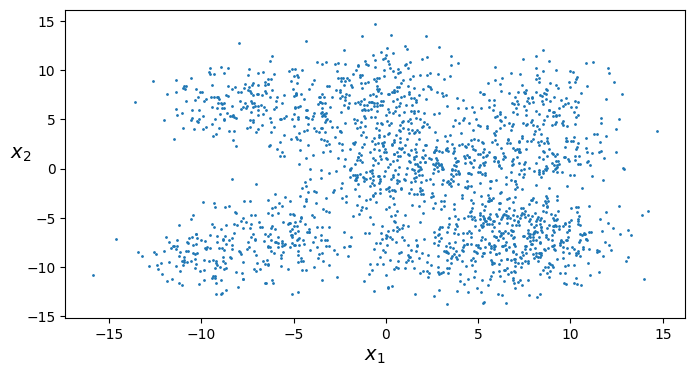

In [3]:
plt.figure(figsize=(8, 4))
plot_clusters(X)
plt.show()

En *Scikit-Learn* puedes usar el objeto [KMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html), indicando el número de clusters deseado.  

In [4]:
from sklearn.cluster import KMeans
k = len(blob_centers)
kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(X)
y_pred    

array([10,  9,  0, ..., 12,  3, 11], shape=(2000,), dtype=int32)

In [5]:
kmeans.cluster_centers_

array([[-3.70956695,  4.71722091],
       [ 6.05916545, -4.69729936],
       [-9.83286826, -9.07663707],
       [ 1.0636563 , -8.1629889 ],
       [ 0.93460275,  3.52151845],
       [ 8.15321494,  6.95136953],
       [ 9.6587432 , -7.34811315],
       [-8.24109095,  6.99109534],
       [-5.52421844, -6.53737681],
       [-0.37432302, -1.28811766],
       [-0.19137081,  8.92210599],
       [ 4.51730503,  0.83296669],
       [ 9.26450525,  1.33165047],
       [ 5.71887419, -9.69086937]])

In [6]:
X_new = np.array([[0, 2], [3, 2], [-3, 3], [-3, 2.5]])
kmeans.predict(X_new)

array([ 4, 11,  0,  0], dtype=int32)

In [9]:
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=10, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=2, linewidths=10,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                cmap="Pastel2")
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)

    if show_xlabels:
        plt.xlabel("$x_1$", fontsize=14)
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", fontsize=14, rotation=0)
    else:
        plt.tick_params(labelleft=False)

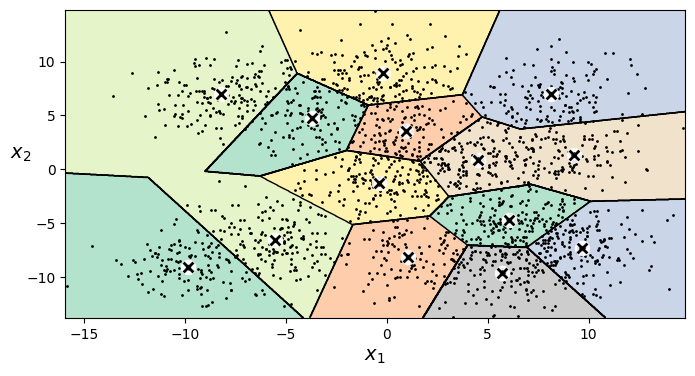

In [10]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans, X)
plt.show()


En lugar de asignar un grupo a cada muestra (*hard clustering*) se le puede asignar una puntuación (*soft clustering*) en función de su distancia al centroide.

In [11]:
kmeans.transform(X_new)

array([[ 4.59827972,  9.03146193, 14.81138707, 10.21849833,  1.78563733,
         9.53891892, 13.44167176,  9.63465686, 10.16876552,  3.30935575,
         6.92475083,  4.66562016,  9.28858162, 13.01468204],
       [ 7.23889343,  7.36290105, 16.95212071, 10.34580931,  2.56532341,
         7.14644558, 11.47719829, 12.29931537, 12.06437329,  4.71145133,
         7.62236177,  1.91420513,  6.30005691, 12.0028623 ],
       [ 1.85804545, 11.88767833, 13.87563517, 11.87963062,  3.96901503,
        11.83247754, 16.3501445 ,  6.58770646,  9.86576075,  5.02813412,
         6.5543678 ,  7.82342049, 12.37745851, 15.39730277],
       [ 2.32799352, 11.57020297, 13.44271603, 11.4110751 ,  4.06504597,
        12.00870077, 16.03836376,  6.90209908,  9.38327546,  4.60912302,
         7.00941105,  7.69992694, 12.32002961, 14.98786386]])

Este algoritmo comienza eligiendo algunos puntos al azar como centroides. Luego, en cada paso, agrupa las muestras según el centroide más cercano y actualiza la posición de cada centroide calculando el promedio de los puntos que le han tocado. Así, poco a poco, los grupos y sus centros se van ajustando hasta que todo queda bien repartido.



In [12]:
# kmeans_iter1 = KMeans(n_clusters=5, init="random", n_init=1,
                    #  algorithm="full", max_iter=1, random_state=1)
# kmeans_iter1 = KMeans(n_clusters=5, init="random", n_init=1,
                    #  algorithm="lloyd", max_iter=1, random_state=1)
# kmeans_iter1 = KMeans(n_clusters=5, init="random", n_init=5,
                    #  algorithm="elkan", max_iter=1, random_state=1)
# Configuración del modelo K-Means con inicialización inteligente
kmeans_iter1 = KMeans(n_clusters=k, init="k-means++", n_init=1,
                      algorithm="elkan", max_iter=3, random_state=4)
# kmeans_iter2 = KMeans(n_clusters=5, init="random", n_init=1,
#                      algorithm="full", max_iter=2, random_state=1)
# kmeans_iter2 = KMeans(n_clusters=5, init="random", n_init=5,
#                      algorithm="elkan", max_iter=2, random_state=1)
kmeans_iter2 = KMeans(n_clusters=k, init="k-means++", n_init=1,
                     algorithm="elkan", max_iter=2, random_state=1)

# kmeans_iter3 = KMeans(n_clusters=5, init="random", n_init=1,
#                      algorithm="full", max_iter=3, random_state=1)
# kmeans_iter3 = KMeans(n_clusters=5, init="random", n_init=5,
#                      algorithm="elkan", max_iter=3, random_state=1)
kmeans_iter3 = KMeans(n_clusters=k, init="k-means++", n_init=1,
                     algorithm="elkan", max_iter=3, random_state=5)
kmeans_iter1.fit(X)
print(kmeans_iter1)
kmeans_iter2.fit(X)
print(kmeans_iter2)
kmeans_iter3.fit(X)
print(kmeans_iter3)

KMeans(algorithm='elkan', max_iter=3, n_clusters=14, n_init=1, random_state=4)
KMeans(algorithm='elkan', max_iter=2, n_clusters=14, n_init=1, random_state=1)
KMeans(algorithm='elkan', max_iter=3, n_clusters=14, n_init=1, random_state=5)


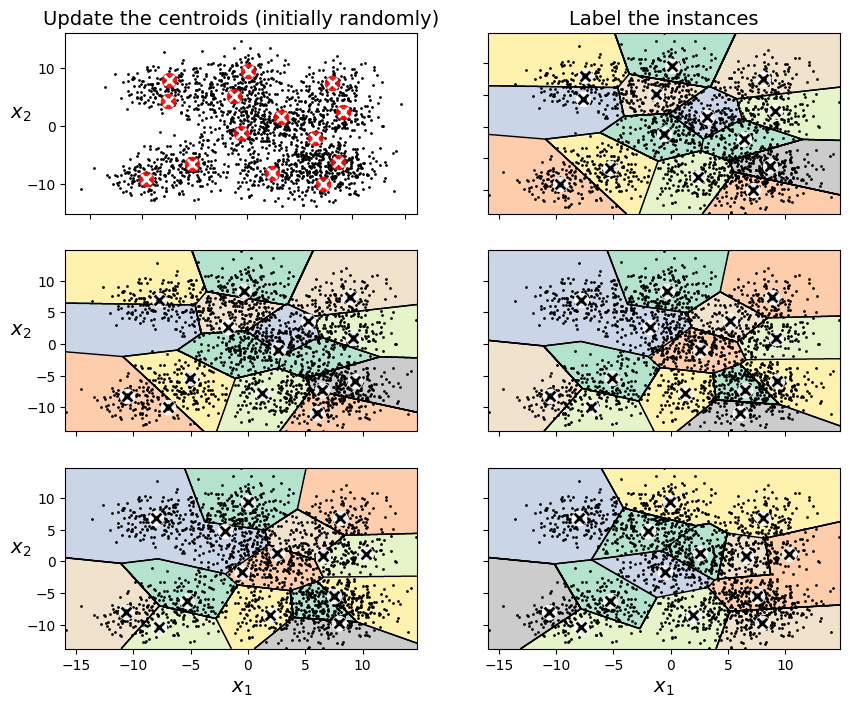

In [13]:
plt.figure(figsize=(10, 8))

plt.subplot(321)
plot_data(X)
plot_centroids(kmeans_iter1.cluster_centers_, circle_color='r', cross_color='w')
plt.ylabel("$x_2$", fontsize=14, rotation=0)
plt.tick_params(labelbottom=False)
plt.title("Update the centroids (initially randomly)", fontsize=14)

plt.subplot(322)
plot_decision_boundaries(kmeans_iter1, X, show_xlabels=False, show_ylabels=False)
plt.title("Label the instances", fontsize=14)

plt.subplot(323)
plot_decision_boundaries(kmeans_iter1, X, show_centroids=False, show_xlabels=False)
plot_centroids(kmeans_iter2.cluster_centers_)

plt.subplot(324)
plot_decision_boundaries(kmeans_iter2, X, show_xlabels=False, show_ylabels=False)

plt.subplot(325)
plot_decision_boundaries(kmeans_iter2, X, show_centroids=False)
plot_centroids(kmeans_iter3.cluster_centers_)

plt.subplot(326)
plot_decision_boundaries(kmeans_iter3, X, show_ylabels=False)

plt.show()

Esto implica que en función del estado inicial, el algoritmo puede llegar a una solución u otra.

In [14]:
def plot_clusterer_comparison(clusterer1, clusterer2, X, title1=None, title2=None):
    clusterer1.fit(X)
    clusterer2.fit(X)

    plt.figure(figsize=(10, 3.2))

    plt.subplot(121)
    plot_decision_boundaries(clusterer1, X)
    if title1:
        plt.title(title1, fontsize=14)

    plt.subplot(122)
    plot_decision_boundaries(clusterer2, X, show_ylabels=False)
    if title2:
        plt.title(title2, fontsize=14)

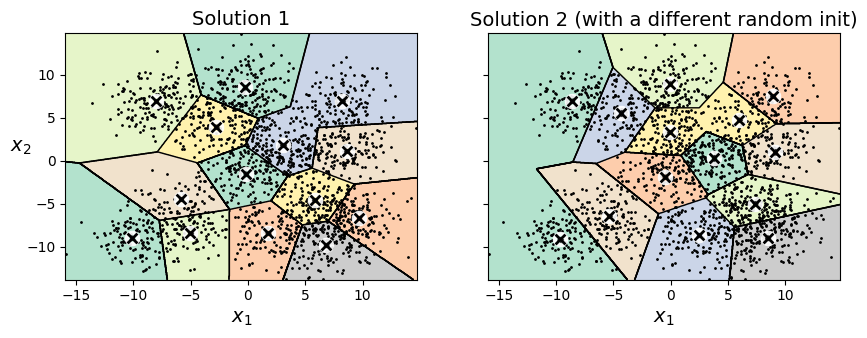

In [15]:
kmeans_rnd_init1 = KMeans(n_clusters=k, init="random", n_init=1,
                         algorithm="elkan", random_state=11)
kmeans_rnd_init2 = KMeans(n_clusters=k, init="random", n_init=1,
                         algorithm="elkan", random_state=19)

plot_clusterer_comparison(kmeans_rnd_init1, kmeans_rnd_init2, X,"Solution 1", "Solution 2 (with a different random init)")

plt.show()

Para evitar que la inicialización afecte demasiado al resultado, podemos probar varias veces con diferentes valores iniciales y elegir la mejor opción, o bien utilizar la inicialización inteligente que viene por defecto en *Scikit-Learn*.

In [16]:
kmeans_rnd_10_inits = KMeans(n_clusters=k, init="random", n_init=10,
                              algorithm="elkan", random_state=11)
kmeans_rnd_10_inits.fit(X)
print(kmeans_rnd_10_inits)

KMeans(algorithm='elkan', init='random', n_clusters=14, n_init=10,
       random_state=11)


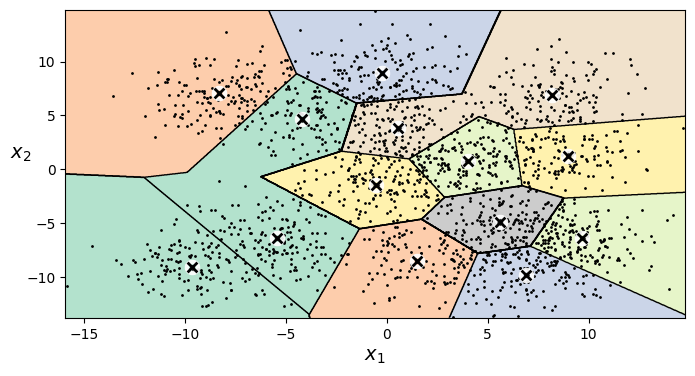

In [17]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans_rnd_10_inits, X)
plt.show()

Existen varias formas de mejorar el algoritmo *K-Means*. Por ejemplo, hay versiones más rápidas (como la que usa *Scikit-Learn* por defecto, que optimiza el cálculo de distancias) y también está el *mini-batch K-Means*, ideal cuando el conjunto de datos es tan grande que no cabe en memoria. A continuación veremos cómo funciona este último usando el dataset MNIST, empleando el objeto [MiniBatchKMeans]

In [18]:
def load_next_batch(batch_size):
    return X[np.random.choice(len(X), batch_size, replace=False)]

In [19]:
from sklearn.cluster import MiniBatchKMeans

k = 5
n_init = 10
n_iterations = 100
batch_size = 100
init_size = 500
evaluate_on_last_n_iters = 10

best_kmeans = None

for init in range(n_init):
    minibatch_kmeans = MiniBatchKMeans(n_clusters=k, init_size=init_size)
    X_init = load_next_batch(init_size)
    minibatch_kmeans.partial_fit(X_init)

    minibatch_kmeans.sum_inertia_ = 0
    for iteration in range(n_iterations):
        X_batch = load_next_batch(batch_size)
        minibatch_kmeans.partial_fit(X_batch)
        if iteration >= n_iterations - evaluate_on_last_n_iters:
            minibatch_kmeans.sum_inertia_ += minibatch_kmeans.inertia_

    if (best_kmeans is None or
        minibatch_kmeans.sum_inertia_ < best_kmeans.sum_inertia_):
        best_kmeans = minibatch_kmeans

In [20]:
best_kmeans.score(X)

-26202.141701218432

El algoritmo de mini-batch K-Means funciona mucho más rápido que el K-Means tradicional, aunque normalmente sacrifica algo de precisión a cambio de esa velocidad.



### Encontrando el número óptimo de grupos

El número de clusters es un parámetro clave que debemos elegir al usar estos modelos. Cuando no tenemos etiquetas, no sabemos cuál es el valor ideal, así que probamos varios y usamos métricas para decidir. Una de las más útiles es el silhouette score, que mide qué tan bien está cada muestra dentro de su grupo: valores cercanos a 1 indican que la muestra está bien agrupada, cerca de 0 que está en el límite entre grupos, y negativos que probablemente está en el grupo equivocado.



In [20]:
from sklearn.metrics import silhouette_score
silhouette_score(X, kmeans.labels_)

0.3656734022121803

Calculando la métrica para diferentes números de *clusters* podemos encontrar el valor óptimo.

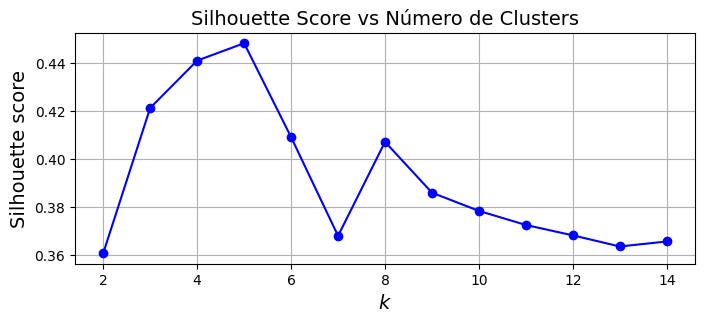

In [21]:
kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(X) for k in range(1, 10)]
silhouette_scores = [silhouette_score(X, model.labels_) for model in kmeans_per_k[1:]]

max_k = min(20, len(blob_centers)) 
kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(X) for k in range(1, max_k + 1)]
silhouette_scores = [silhouette_score(X, model.labels_) for model in kmeans_per_k[1:]]

ks = list(range(2, max_k + 1))

plt.figure(figsize=(8, 3))
plt.plot(ks, silhouette_scores, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)
plt.title("Silhouette Score vs Número de Clusters", fontsize=14)
plt.grid(True)
plt.show()

### ELBOW METHOD 

Calcula la inercia para distintos valores de k

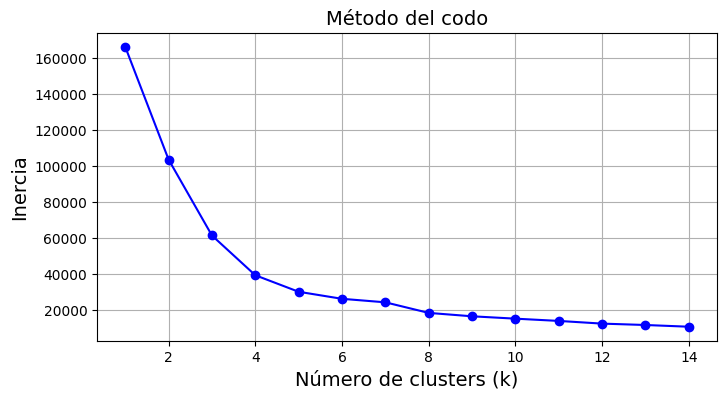

In [22]:
inertias = []
K = range(1, max_k + 1)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42).fit(X)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K, inertias, "bo-")
plt.xlabel("Número de clusters (k)", fontsize=14)
plt.ylabel("Inercia", fontsize=14)
plt.title("Método del codo", fontsize=14)
plt.grid(True)
plt.show()


También es muy útil visualizar los diagramas de silueta, en el que visualizaremos todos los coeficientes de silueta ordenados por grupos y su valor.

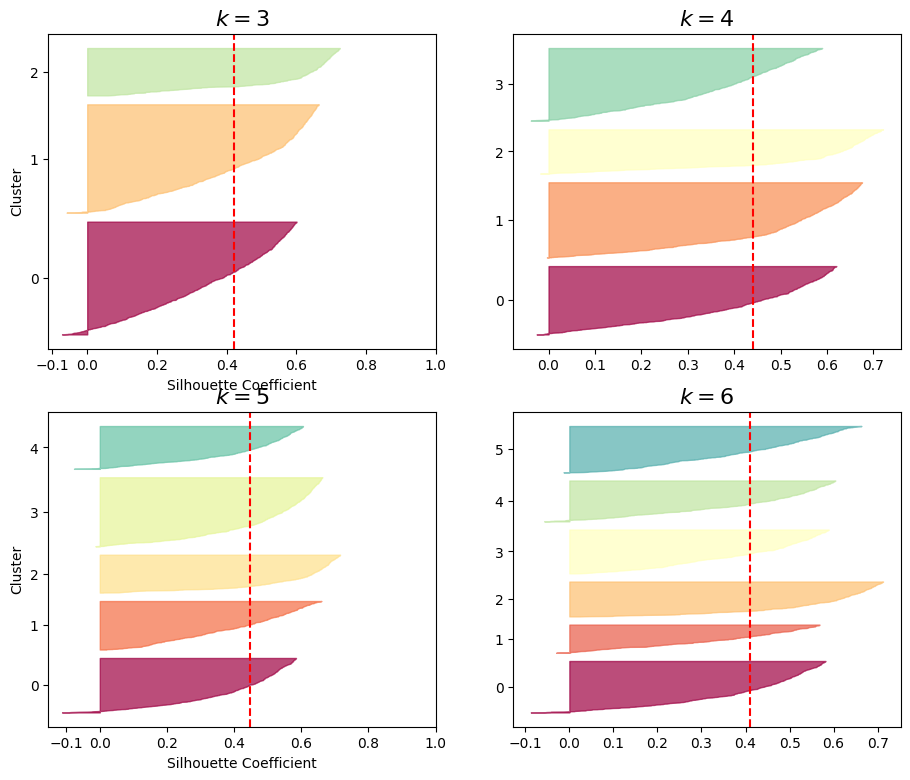

In [23]:
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter
import matplotlib as mpl

plt.figure(figsize=(11, 9))

valid_ks = [k for k in (3, 4, 5, 6) if k <= len(kmeans_per_k)]  # Filtrar solo los ks válidos


for plot_idx, k in enumerate(valid_ks):
    plt.subplot(2, 2, plot_idx + 1)  # enumerar para evitar errores


    y_pred = kmeans_per_k[k - 1].labels_
    silhouette_coefficients = silhouette_samples(X, y_pred)

    padding = len(X) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = mpl.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    if k in (3, 5):
        plt.ylabel("Cluster")

    #if k in (5, 6):
        plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
        plt.xlabel("Silhouette Coefficient")
    #else:
        #plt.tick_params(labelbottom=False)

    plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title("$k={}$".format(k), fontsize=16)

plt.show()

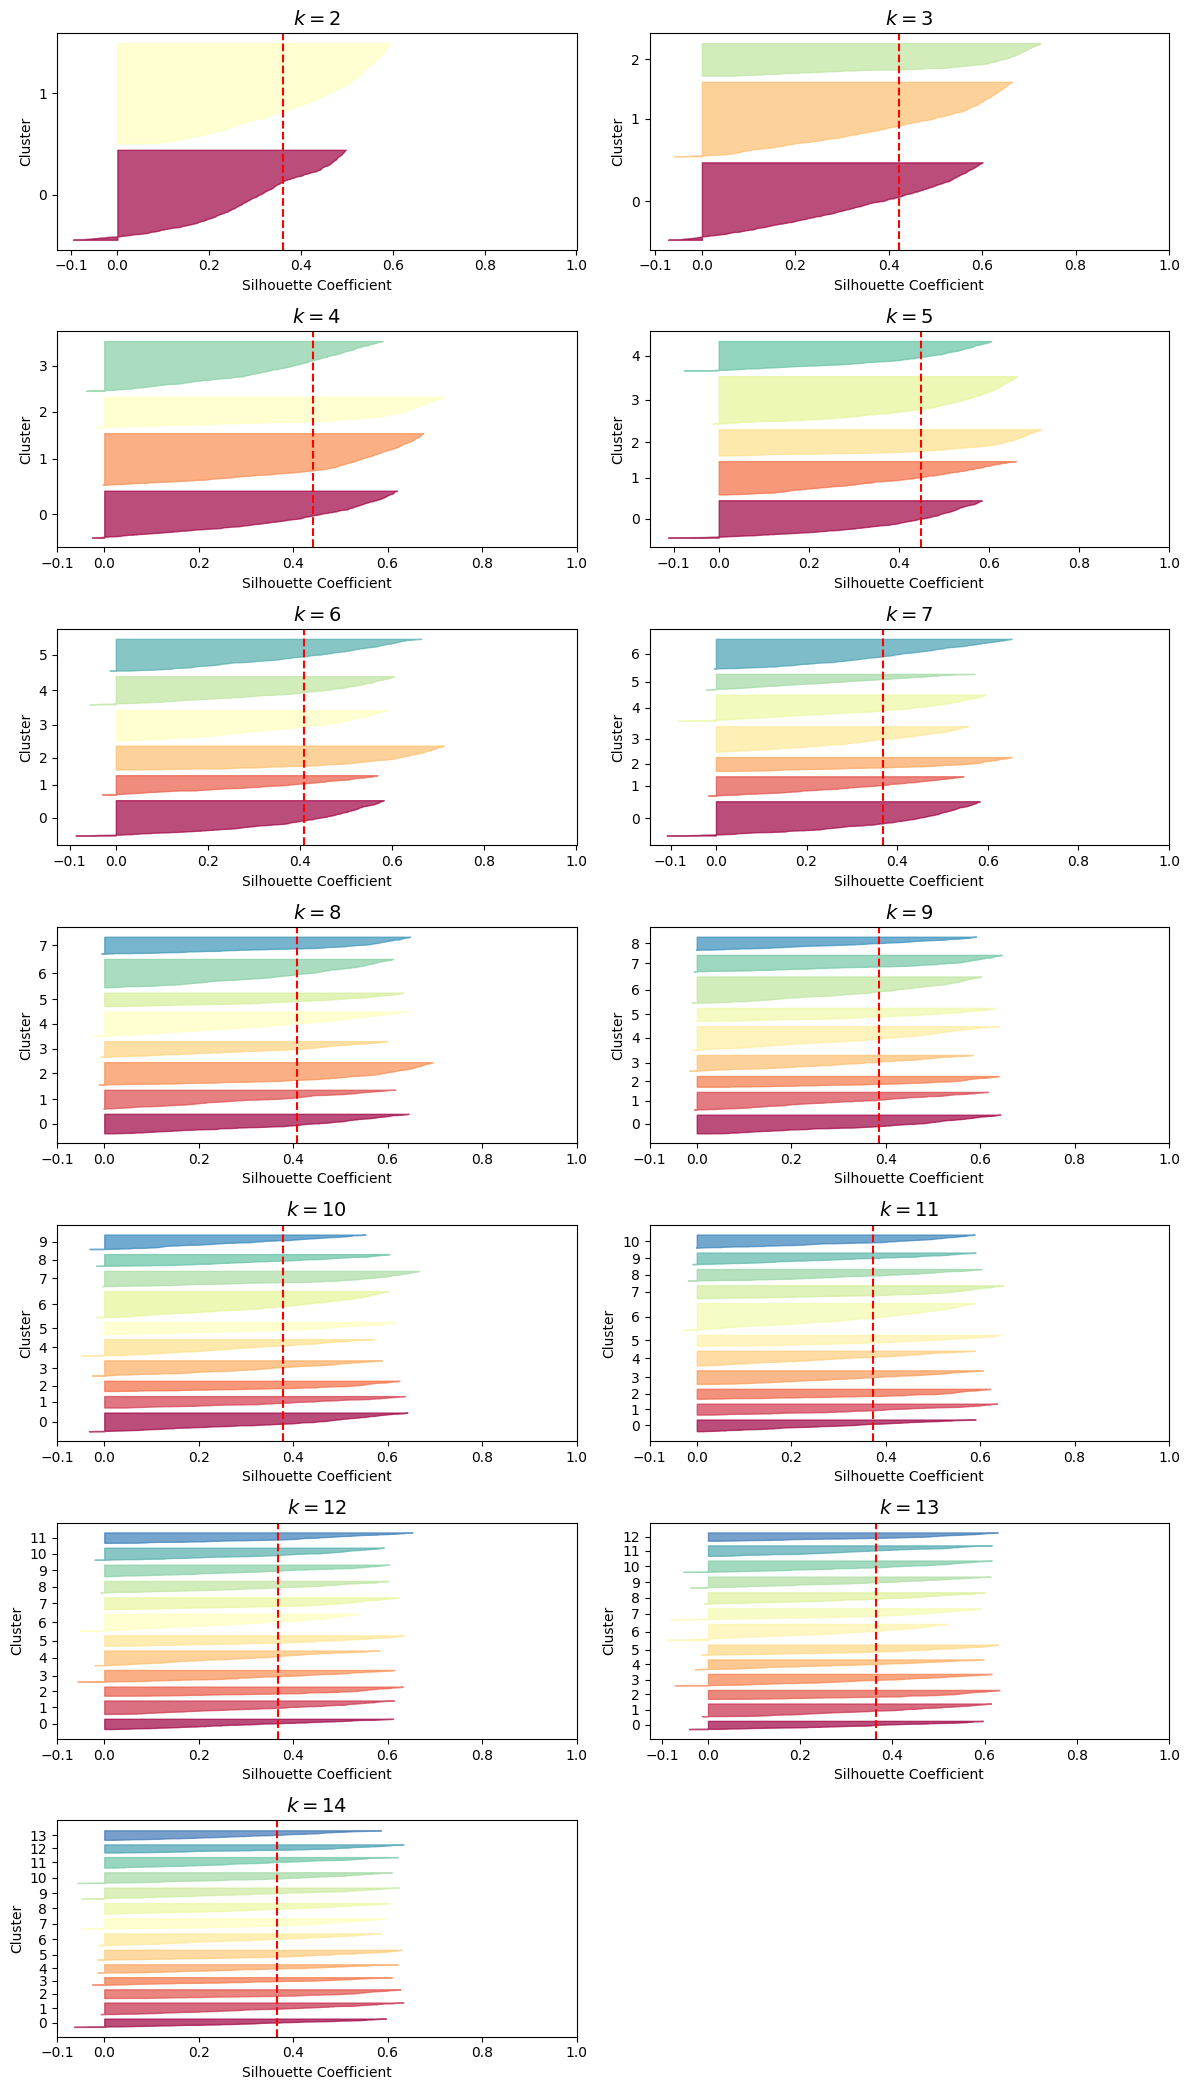

In [24]:
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter
import matplotlib as mpl

n_ks = len(kmeans_per_k)  # Total de modelos entrenados
plt.figure(figsize=(12, 3 * ((n_ks - 1) // 2 + 1)))  # ajustar el alto automáticamente

for plot_idx, k in enumerate(range(2, n_ks + 1)):  # desde k=2 hasta máximo
    plt.subplot((n_ks - 1) // 2 + 1, 2, plot_idx + 1)

    y_pred = kmeans_per_k[k - 1].labels_
    silhouette_coefficients = silhouette_samples(X, y_pred)

    padding = len(X) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = mpl.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    plt.ylabel("Cluster")

    plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
    plt.xlabel("Silhouette Coefficient")

    if k - 2 < len(silhouette_scores):
        plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title(f"$k={k}$", fontsize=14)

plt.tight_layout()
plt.show()


### K-Means para aprendizaje semi-supervisado.

El aprendizaje semi-supervisado, también conocido como Semi-supervised Learning, reúne técnicas que nos ayudan a entrenar modelos cuando solo tenemos una parte de los datos etiquetados. En esta sección veremos, de forma práctica y sencilla, cómo aplicar este enfoque usando el dataset bloodMNIST y el algoritmo K-Means. Para comenzar, cargamos el dataset y prepararemos los datos.



In [6]:
from pathlib import Path

import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split

image_dir = Path(r"C:\Users\elmer\Documents\archive\all unlabeled")
image_paths = sorted(image_dir.glob("*.jpg"))

image_shape = (32, 32, 3)

class_names = sorted({path.stem.rsplit("_", 1)[0] for path in image_paths})
class_to_id = {class_name: idx for idx, class_name in enumerate(class_names)}

X_all = np.stack([
    np.asarray(
        Image.open(path).convert("RGB").resize(image_shape[:2], Image.BILINEAR),
        dtype=np.float32,
    )
    / 255.0
    for path in image_paths
]).reshape(len(image_paths), -1)

y_all = np.array([
    class_to_id[path.stem.rsplit("_", 1)[0]]
    for path in image_paths
], dtype=np.int64)

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

print("Clases:", class_names)
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

Clases: ['oral_normal', 'oral_scc']
X_train shape: (6400, 3072)
y_train shape: (6400,)
X_val shape: (1601, 3072)
X_test shape: (2001, 3072)
y_test shape: (2001,)


Imagina que tenemos un conjunto de imágenes sin ninguna etiqueta, es decir, solo contamos con los datos X y no sabemos a qué clase pertenece cada imagen, ni cuántas clases diferentes hay. En este caso, una buena estrategia sería aplicar el algoritmo K-Means y pedirle que agrupe las imágenes en, por ejemplo, 50 grupos. Así, podríamos identificar cuáles son las imágenes más representativas de cada grupo y hacernos una idea de la variedad que existe en el dataset.

In [7]:
# ============================================================
# PARÁMETRO PRINCIPAL: Cambia este valor según necesites
# ============================================================
k = 50  # Número de clusters (cambia aquí y ejecuta todas las celdas de abajo)
# ============================================================


In [8]:
from sklearn.cluster import KMeans
# k ya está definido en la celda anterior
print(f'Aplicando KMeans con k={k} clusters...')
kmeans = KMeans(n_clusters=k, random_state=42)
X_digits_dist = kmeans.fit_transform(X_train)
print(f'KMeans entrenado. X_digits_dist shape: {X_digits_dist.shape}')


Aplicando KMeans con k=50 clusters...
KMeans entrenado. X_digits_dist shape: (6400, 50)


In [9]:
print(X_digits_dist.shape)
print(X_digits_dist)

(6400, 50)
[[14.056832  14.540046   9.169365  ... 12.301588  16.399614   9.415957 ]
 [11.063909  14.87987   15.072766  ... 14.083134  17.388384  12.635445 ]
 [ 9.1973505  9.782493   7.2973566 ... 10.119343  13.47183    5.268262 ]
 ...
 [10.919162  11.408381   8.285347  ...  8.963656  12.946279   7.2747035]
 [ 9.790987  10.572265  10.844843  ...  9.849214  12.960794   7.5591135]
 [10.071591  13.005332   7.268805  ... 12.397732  16.192493   7.6041307]]


In [10]:
idxs = np.argmin(X_digits_dist, axis=0)
X_representative_digits = X_train[idxs]


In [11]:
print(X_representative_digits.shape)
print(X_representative_digits)

(50, 3072)
[[0.9882353  1.         1.         ... 0.4627451  0.34901962 0.7019608 ]
 [0.7490196  0.8156863  0.8117647  ... 0.8039216  0.84705883 0.9372549 ]
 [0.44313726 0.40784314 0.61960787 ... 0.49411765 0.47058824 0.6117647 ]
 ...
 [0.6392157  0.6        0.7882353  ... 0.8392157  0.94509804 0.91764706]
 [0.6392157  0.60784316 0.7529412  ... 0.58431375 0.5764706  0.7294118 ]
 [0.6509804  0.6745098  0.81960785 ... 0.6156863  0.6        0.6901961 ]]


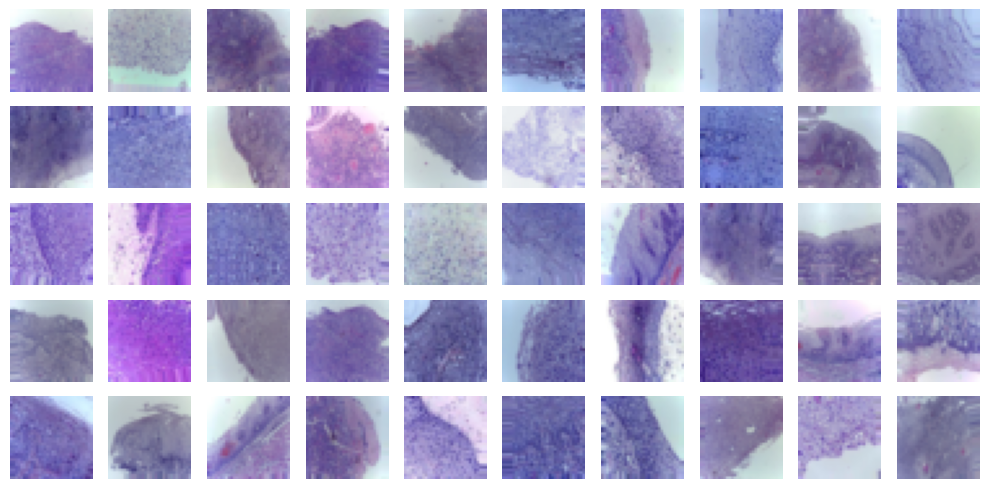

In [12]:
import matplotlib.pyplot as plt
import math

# Determine layout based on number of representative images
n = len(X_representative_digits)
cols = 10
rows = math.ceil(n / cols)
plt.figure(figsize=(cols, rows))

# Use the image_shape variable (height, width, channels) defined earlier
h, w, c = image_shape
for index, X_representative_digit in enumerate(X_representative_digits):
    plt.subplot(rows, cols, index + 1)
    img = X_representative_digit.reshape((h, w, c))
    plt.imshow(img)
    plt.axis('off')
plt.tight_layout()
plt.show()


El siguiente paso consiste en anotar manualmente estas etiquetas (aquí haremos trampas ya que disponemos de dichas etiquetas :p).

In [189]:
y_representative_digits = y_train[idxs]

In [190]:
import numpy as np

# Diagnostic checks before training
print('Defined variables:')
print('  X_representative_digits:', 'X_representative_digits' in globals())
print('  y_representative_digits:', 'y_representative_digits' in globals())
print('  X_test:', 'X_test' in globals())
print('  y_test:', 'y_test' in globals())

if 'X_representative_digits' in globals():
    print('X_representative_digits shape:', X_representative_digits.shape)
if 'y_representative_digits' in globals():
    print('y_representative_digits shape:', y_representative_digits.shape)
    unique, counts = np.unique(y_representative_digits, return_counts=True)
    print('unique labels:', unique)
    print('counts:', counts)
    if np.any(counts < 2):
        print('WARNING: Algunas clases tienen <2 muestras. Considera anotar más representantes o usar otro clasificador.')

if 'X_test' in globals():
    print('X_test shape:', X_test.shape)
if 'y_test' in globals():
    print('y_test shape:', y_test.shape)

print('Si todo parece correcto, ejecuta la celda de entrenamiento. Si falla, pega aquí la traza de error.')


Defined variables:
  X_representative_digits: True
  y_representative_digits: True
  X_test: True
  y_test: True
X_representative_digits shape: (50, 3072)
y_representative_digits shape: (50,)
unique labels: [0 1]
counts: [17 33]
X_test shape: (2001, 3072)
y_test shape: (2001,)
Si todo parece correcto, ejecuta la celda de entrenamiento. Si falla, pega aquí la traza de error.


Y entrenaremos un clasificados usando estas imágenes representativas.

In [191]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

# Verificar que las variables necesarias estén definidas
if 'X_representative_digits' not in globals() or 'y_representative_digits' not in globals():
    raise RuntimeError('Variables X_representative_digits o y_representative_digits no definidas. Ejecuta las celdas de carga y KMeans primero.')

# Normalizar tipos y formas
X_rep = np.asarray(X_representative_digits)
y_rep = np.asarray(y_representative_digits).astype(int).ravel()
X_test_arr = np.asarray(X_test)
y_test_arr = np.asarray(y_test).astype(int).ravel()

# Aplanar si hace falta
if X_rep.ndim > 2:
    X_rep = X_rep.reshape(len(X_rep), -1)
if X_test_arr.ndim > 2:
    X_test_arr = X_test_arr.reshape(len(X_test_arr), -1)

# Escalado
scaler = StandardScaler()
X_rep_scaled = scaler.fit_transform(X_rep)
X_test_scaled = scaler.transform(X_test_arr)

# Comprobar recuentos por clase y elegir clasificador
unique, counts = np.unique(y_rep, return_counts=True)
print('Representative class counts:', dict(zip(unique, counts)))
if np.any(counts < 2):
    print('Algunas clases tienen <2 representantes: usaré KNeighborsClassifier como fallback')
    clf = KNeighborsClassifier(n_neighbors=1)
else:
    # Construir argumentos compatibles según la versión/firmas de sklearn
    from inspect import signature as _signature
    _sig = _signature(LogisticRegression.__init__)
    _kwargs = {"solver": "saga", "max_iter": 10000, "random_state": 42}
    if "multi_class" in _sig.parameters:
        _kwargs["multi_class"] = "ovr"
    clf = LogisticRegression(**_kwargs)

try:
    get_ipython().run_line_magic('time', 'clf.fit(X_rep_scaled, y_rep)')
    print('Train score:', clf.score(X_rep_scaled, y_rep))
    print('Test score:', clf.score(X_test_scaled, y_test_arr))
except Exception as e:
    print('Error al entrenar:', e)
    if not isinstance(clf, KNeighborsClassifier):
        print('Intentando fallback con KNeighborsClassifier...')
        clf2 = KNeighborsClassifier(n_neighbors=1)
        get_ipython().run_line_magic('time', 'clf2.fit(X_rep_scaled, y_rep)')
        print('KNN test score:', clf2.score(X_test_scaled, y_test_arr))

Representative class counts: {np.int64(0): np.int64(17), np.int64(1): np.int64(33)}
CPU times: total: 3 s
Wall time: 3.09 s
Train score: 1.0
Test score: 0.5502248875562219


Como puedes observar hemos obtenido una precisión de casi el $44%$ habiendo anotado simplemente 50 imágenes, pero aquellas más representativas. Entrenar el mismo modelo con 50 imágenes aleatorias nos daría peores resultados.

In [192]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from inspect import signature as _signature

# Sample 50 random training examples
idxs = np.random.choice(len(X_train), 50, replace=False)
X_sample = X_train[idxs]
y_sample = np.asarray(y_train[idxs]).astype(int).ravel()

# Build compatible kwargs for LogisticRegression
_sig = _signature(LogisticRegression.__init__)
_kwargs = {"solver": "lbfgs", "max_iter": 5000, "random_state": 42}
if "multi_class" in _sig.parameters:
    _kwargs["multi_class"] = "ovr"

log_reg = LogisticRegression(**_kwargs)
get_ipython().run_line_magic('time', 'log_reg.fit(X_sample, y_sample)')
print('Sample train score:', log_reg.score(X_sample, y_sample))
print('Test score:', log_reg.score(X_test, y_test))

CPU times: total: 109 ms
Wall time: 125 ms
Sample train score: 1.0
Test score: 0.6316841579210395


A veces, al entrenar modelos de Machine Learning, no importa tanto tener muchos datos, sino que sean los más útiles y representativos.
Una vez que hemos entrenado un clasificador con las imágenes más representativas, podemos aprovecharlo para etiquetar automáticamente el resto del conjunto. Para ello, asignamos a todas las imágenes de cada grupo la misma etiqueta que le dimos a su representante.

In [193]:
y_train_propagated = np.empty(len(X_train), dtype=np.int64)
for i in range(k):
    # asegurarse de asignar ints, en caso de que y_representative_digits sea float
    y_train_propagated[kmeans.labels_==i] = int(y_representative_digits[i])

In [194]:
from sklearn.linear_model import LogisticRegression
from inspect import signature as _signature

_sig = _signature(LogisticRegression.__init__)
_kwargs = {"solver": "lbfgs", "max_iter": 5000, "random_state": 42}
if "multi_class" in _sig.parameters:
    _kwargs["multi_class"] = "ovr"

log_reg3 = LogisticRegression(**_kwargs)
get_ipython().run_line_magic('time', 'log_reg3.fit(X_train[:1000], y_train_propagated[:1000])')
print('Train score:', log_reg3.score(X_train[:1000], y_train_propagated[:1000]))
print('Test score:', log_reg3.score(X_test, y_test))

CPU times: total: 9.69 s
Wall time: 2.2 s
Train score: 0.947
Test score: 0.5347326336831584


A veces, al intentar mejorar el modelo añadiendo más datos etiquetados automáticamente, el resultado puede ser peor. Esto ocurre porque no todas las imágenes quedan bien agrupadas y se introduce ruido en el entrenamiento. Para evitarlo, podemos limitar el etiquetado solo a las muestras que estén más cerca de los representantes de cada grupo, o bien recurrir a técnicas de aprendizaje activo para seleccionar mejor qué ejemplos anotar.

### Aprendizaje Activo

El aprendizaje activo (o *Active Learning*) consiste en entrenar modelos de ML de manera iterativa, incluyendo en cada iteración nuevas muestras al dataset focalizando en ejemplos en loa que el modelo tenga más problemas.

In [195]:
probas = log_reg3.predict_proba(X_train[:1000])
labels_ixs = np.argmax(probas, axis=1)
labels = np.array([proba[ix] for proba, ix in zip(probas, labels_ixs)])
sorted_ixs = np.argsort(labels)
labels[sorted_ixs[:10]]

array([0.50023658, 0.5010905 , 0.50121756, 0.50134569, 0.50146779,
       0.50205453, 0.50246123, 0.50327022, 0.50441036, 0.50441149])

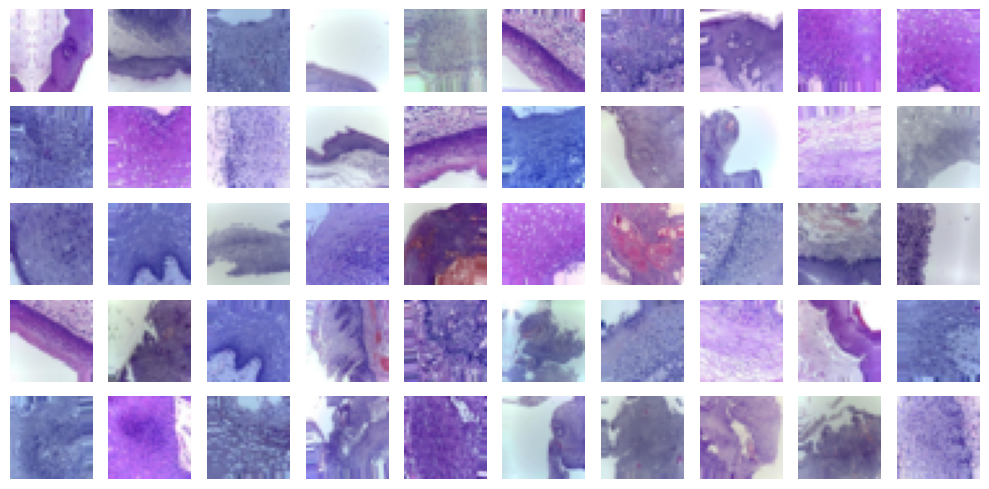

In [196]:
import math

X_lowest = X_train[:1000][sorted_ixs[:k]]
h, w, c = image_shape  # (32, 32, 3)

# Calcular grilla dinámicamente
cols = 10
rows = math.ceil(len(X_lowest) / cols)

plt.figure(figsize=(cols, rows))
for index, img in enumerate(X_lowest):
    plt.subplot(rows, cols, index + 1)
    img_reshaped = img.reshape((h, w, c))
    plt.imshow(img_reshaped)
    plt.axis('off')
plt.tight_layout()
plt.show()


In [197]:
y_lowest = y_train[:1000][sorted_ixs[:k]]
y_lowest

array([0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 0])

In [198]:
y_train2 = y_train_propagated[:1000].copy()
y_train2[sorted_ixs[:k]] = y_lowest

In [199]:
from sklearn.linear_model import LogisticRegression
from inspect import signature as _signature

_sig = _signature(LogisticRegression.__init__)
_kwargs = {"solver": "lbfgs", "max_iter": 5000, "random_state": 42}
if "multi_class" in _sig.parameters:
    _kwargs["multi_class"] = "ovr"

log_reg5 = LogisticRegression(**_kwargs)
get_ipython().run_line_magic('time', 'log_reg5.fit(X_train[:1000], y_train2)')
print('Train score:', log_reg5.score(X_train[:1000], y_train2))
print('Test score:', log_reg5.score(X_test, y_test))

CPU times: total: 8.14 s
Wall time: 2.36 s
Train score: 0.949
Test score: 0.5402298850574713
